<a href="https://colab.research.google.com/github/sajjkavinda/ML-based-Intrution-detection-system/blob/main/Feature_Engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Feature Engineering and Dataset Optimisation

**Dataset:** CSE-CIC-IDS2018

This notebook performs the feature engineering and optimisation stage of the proposed intrusion detection framework.

The objective of this stage is to identify relevant network traffic features, reduce unnecessary feature complexity, and prepare an optimised dataset for machine learning model development.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np

from pathlib import Path

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

Set dataset and output paths

In [3]:
PROJECT_DIR = Path("/content/drive/MyDrive/MSc_Dissertation")

DATASET_DIR = PROJECT_DIR / "Dataset"

PROCESSED_DIR = DATASET_DIR / "Processed"

RESULTS_DIR = PROJECT_DIR / "Results"

RESULTS_DIR.mkdir(exist_ok=True)

DATA_FILE = PROCESSED_DIR / "cleaned_dataset.csv"

Load the cleaned subset of the dataset

In [4]:
df = pd.read_csv(DATA_FILE)

print("Dataset shape:")
print(df.shape)

df.head()

Dataset shape:
(191457, 79)


,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,Fwd Pkt Len Std,Bwd Pkt Len Max,Bwd Pkt Len Min,Bwd Pkt Len Mean,Bwd Pkt Len Std,Flow Byts/s,Flow Pkts/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Tot,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Tot,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Len,Bwd Header Len,Fwd Pkts/s,Bwd Pkts/s,Pkt Len Min,Pkt Len Max,Pkt Len Mean,Pkt Len Std,Pkt Len Var,FIN Flag Cnt,SYN Flag Cnt,RST Flag Cnt,PSH Flag Cnt,ACK Flag Cnt,URG Flag Cnt,CWE Flag Count,ECE Flag Cnt,Down/Up Ratio,Pkt Size Avg,Fwd Seg Size Avg,Bwd Seg Size Avg,Fwd Byts/b Avg,Fwd Pkts/b Avg,Fwd Blk Rate Avg,Bwd Byts/b Avg,Bwd Pkts/b Avg,Bwd Blk Rate Avg,Subflow Fwd Pkts,Subflow Fwd Byts,Subflow Bwd Pkts,Subflow Bwd Byts,Init Fwd Win Byts,Init Bwd Win Byts,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,37654.0,6.0,4097324.0,5.0,3.0,935.0,368.0,935.0,0.0,187.00,418.144712,368.0,0.0,122.666667,212.464899,318.012439,1.952494,585332.0000,1511103.593,4012031.0,6.0,4097324.0,1024331.00,1991918.154,4012039.0,25.0,50945.0,25472.5,5625.034444,29450.0,21495.0,0.0,0.0,0.0,0.0,168.0,104.0,1.220309,0.732185,0.0,935.0,144.777778,320.352063,102625.44440,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,162.875000,187.00,122.666667,0.0,0.0,0.0,0.0,0.0,0.0,5.0,935.0,3.0,368.0,237.0,211.0,1.0,32.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,60318.0,6.0,4334139.0,5.0,3.0,935.0,323.0,935.0,0.0,187.00,418.144712,323.0,0.0,107.666667,186.484137,290.253727,1.845811,619162.7143,1573398.786,4186439.0,8.0,4334139.0,1083534.75,2069194.643,4186447.0,47.0,116546.0,58273.0,54865.829370,97069.0,19477.0,0.0,0.0,0.0,0.0,168.0,104.0,1.153632,0.692179,0.0,935.0,139.777778,316.763625,100339.19440,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,157.250000,187.00,107.666667,0.0,0.0,0.0,0.0,0.0,0.0,5.0,935.0,3.0,323.0,219.0,211.0,1.0,32.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,56576.0,6.0,4255389.0,4.0,5.0,935.0,337.0,935.0,0.0,233.75,467.500000,337.0,0.0,67.400000,150.710982,298.915093,2.114965,531923.6250,1466901.119,4162121.0,4.0,4226547.0,1408849.00,2384410.049,4162127.0,29666.0,93268.0,23317.0,15539.715910,34443.0,313.0,0.0,0.0,0.0,0.0,136.0,168.0,0.939985,1.174981,0.0,935.0,127.200000,302.947667,91777.28889,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,141.333333,233.75,67.400000,0.0,0.0,0.0,0.0,0.0,0.0,4.0,935.0,5.0,337.0,219.0,225.0,1.0,32.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,40018.0,6.0,5200477.0,5.0,3.0,935.0,380.0,935.0,0.0,187.00,418.144712,380.0,0.0,126.666667,219.393102,252.861420,1.538320,742925.2857,1930901.732,5121312.0,7.0,5200477.0,1300119.25,2547726.106,5121319.0,32.0,77812.0,38906.0,54673.496320,77566.0,246.0,0.0,0.0,0.0,0.0,168.0,104.0,0.961450,0.576870,0.0,935.0,146.111111,321.420458,103311.11110,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,164.375000,187.00,126.666667,0.0,0.0,0.0,0.0,0.0,0.0,5.0,935.0,3.0,380.0,219.0,211.0,1.0,32.0,0.0,0.0,0.0,0.0,5121312.0,0.0,5121312.0,5121312.0,0
4,41458.0,6.0,4286809.0,5.0,3.0,935.0,353.0,935.0,0.0,187.00,418.144712,353.0,0.0,117.666667,203.804645,300.456587,1.866190,612401.2857,1559705.244,4148540.0,5.0,4286809.0,1071702.25,2051606.968,4148547.0,21.0,96130.0,48065.0,67467.886420,95772.0,358.0,0.0,0.0,0.0,0.0,168.0,104.0,1.166369,0.699821,0.0,935.0,143.111111,319.082060,101813.36110,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,161.000000,187.00,117.666667,0.0,0.0,0.0,0.0,0.0,0.0,5.0,935.0,3.0,353.0,237.0,211.0,1.0,32.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


Separate Feature and Target

In [5]:
X = df.drop("Label", axis=1)

y = df["Label"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (191457, 78)
Target: (191457,)


Check Feature variance

In [6]:
variance = X.var()

low_variance = variance[variance < 0.01]

print("Low variance features:")
print(low_variance)

print("Number of low variance features:",
      len(low_variance))

Low variance features:
Protocol            0.008664
Fwd PSH Flags       0.000104
Bwd PSH Flags       0.000000
Fwd URG Flags       0.000000
Bwd URG Flags       0.000000
FIN Flag Cnt        0.001970
SYN Flag Cnt        0.000104
RST Flag Cnt        0.000000
CWE Flag Count      0.000000
ECE Flag Cnt        0.000000
Fwd Byts/b Avg      0.000000
Fwd Pkts/b Avg      0.000000
Fwd Blk Rate Avg    0.000000
Bwd Byts/b Avg      0.000000
Bwd Pkts/b Avg      0.000000
Bwd Blk Rate Avg    0.000000
dtype: float64
Number of low variance features: 16


Remove 0 variances

In [7]:
zero_variance_features = [
    col for col in X.columns
    if X[col].nunique() <= 1
]

print(zero_variance_features)

X = X.drop(columns=zero_variance_features)

print(X.shape)

['Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'RST Flag Cnt', 'CWE Flag Count', 'ECE Flag Cnt', 'Fwd Byts/b Avg', 'Fwd Pkts/b Avg', 'Fwd Blk Rate Avg', 'Bwd Byts/b Avg', 'Bwd Pkts/b Avg', 'Bwd Blk Rate Avg']
(191457, 66)


Correlation analysis

In [8]:
correlation_matrix = X.corr()

upper_triangle = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

high_corr_features = [
    column for column in upper_triangle.columns
    if any(upper_triangle[column].abs() > 0.95)
]

print("Highly correlated features:")
print(high_corr_features)

print(
    "Number of correlated features:",
    len(high_corr_features)
)

Highly correlated features:
['Fwd Pkt Len Max', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Std', 'Flow IAT Std', 'Flow IAT Max', 'Fwd IAT Tot', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Fwd Header Len', 'Bwd Header Len', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean', 'Pkt Len Std', 'Pkt Len Var', 'SYN Flag Cnt', 'ACK Flag Cnt', 'Pkt Size Avg', 'Fwd Seg Size Avg', 'Bwd Seg Size Avg', 'Subflow Fwd Pkts', 'Subflow Fwd Byts', 'Subflow Bwd Pkts', 'Subflow Bwd Byts', 'Init Fwd Win Byts', 'Active Max', 'Idle Mean', 'Idle Max', 'Idle Min']
Number of correlated features: 35


Remove only highly correlated features

In [9]:
X = X.drop(columns=high_corr_features)

print("After correlation filtering:")
print(X.shape)

After correlation filtering:
(191457, 31)


Feature importance (Random Forest)

In [10]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X, y)

RandomForestClassifier(n_jobs=-1, random_state=42)

Importance extraction

In [11]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
0,Dst Port,0.240646
16,Bwd IAT Min,0.154637
5,TotLen Fwd Pkts,0.114934
18,Fwd Pkts/s,0.099331
13,Flow IAT Mean,0.063606
2,Flow Duration,0.044883
15,Bwd IAT Tot,0.042124
12,Flow Pkts/s,0.039113
3,Tot Fwd Pkts,0.036967
24,Init Bwd Win Byts,0.026985


Visualize top Features

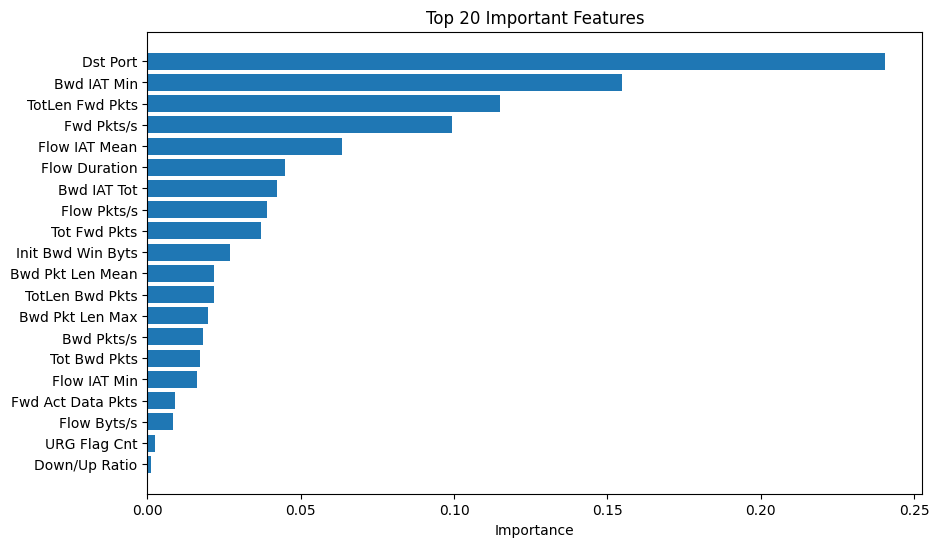

<Figure size 640x480 with 0 Axes>

In [13]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance.head(20)["Feature"],
    feature_importance.head(20)["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")

plt.title(
    "Top 20 Important Features"
)

plt.show()

# Save
plt.savefig(
    RESULTS_DIR / "feature_importance.png",
    bbox_inches="tight"
)

Select important features from the identified features

In [14]:
selected_features = (
    feature_importance
    .head(30)["Feature"]
    .tolist()
)

selected_features

['Dst Port',
 'Bwd IAT Min',
 'TotLen Fwd Pkts',
 'Fwd Pkts/s',
 'Flow IAT Mean',
 'Flow Duration',
 'Bwd IAT Tot',
 'Flow Pkts/s',
 'Tot Fwd Pkts',
 'Init Bwd Win Byts',
 'Bwd Pkt Len Mean',
 'TotLen Bwd Pkts',
 'Bwd Pkt Len Max',
 'Bwd Pkts/s',
 'Tot Bwd Pkts',
 'Flow IAT Min',
 'Fwd Act Data Pkts',
 'Flow Byts/s',
 'URG Flag Cnt',
 'Down/Up Ratio',
 'PSH Flag Cnt',
 'Fwd Seg Size Min',
 'Protocol',
 'Idle Std',
 'Fwd PSH Flags',
 'FIN Flag Cnt',
 'Active Min',
 'Bwd Pkt Len Min',
 'Fwd Pkt Len Min',
 'Active Mean']

Modify the dataset with them

In [15]:
X_selected = X[selected_features]

print(X_selected.shape)

(191457, 30)


Split the dataset to Train and Test sets

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Feature scaling for Logistic Regression and Isolation Forest models

In [17]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

Save the Train and Test data

In [18]:
import pickle

with open(PROCESSED_DIR / "X_train.pkl", "wb") as f:
    pickle.dump(X_train, f)

with open(PROCESSED_DIR / "X_test.pkl", "wb") as f:
    pickle.dump(X_test, f)

with open(PROCESSED_DIR / "y_train.pkl", "wb") as f:
    pickle.dump(y_train, f)

with open(PROCESSED_DIR / "y_test.pkl", "wb") as f:
    pickle.dump(y_test, f)

print("Training and testing datasets saved.")

Training and testing datasets saved.
